In [1]:
def getDist(cord1,cord2):
    return (
        (float(cord1[0])-float(cord2[0]))**2+
        (float(cord1[1])-float(cord2[1]))**2+
        (float(cord1[2])-float(cord2[2]))**2)**0.5 * 10

class gro:    # ndx = {chineID : (start atomNdx, end atomNdx)}
    def __init__(self, groFile, proAtomNdx, ligAtomNdx):
        from tqdm import tqdm
        self.version = "groObj V.2"
        self.type = "Multi Chains"
        with open(groFile, "r") as gro:
            groLines = gro.readlines()
            self.atomNum = groLines[1]
        self.frames = {} # { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
        frameNdx = 0
        atomDic = {}
        resNdx = groLines[2].split()[:-3]
        for line in tqdm(groLines[2:]):
            line_list = line.split()
            if len(line_list) == 3:
                self.frames[frameNdx] = atomDic
                # self.getResData(frameNdx)
                frameNdx = frameNdx + 1
                atomDic = {}
            elif "Title" not in line and len(line.split()) > 3:
                #print(line)
                atomNdx = int(line.split()[2])
                atomDic[atomNdx] = {
                    "resNdx" : int(line.split()[0][:-3]),
                    "coord" : (
                        float(line.split()[3]),
                        float(line.split()[4]),
                        float(line.split()[5])
                    )
                }
        print("> getting resData")
        resData = {
            "proRes": self.getRes(ndx=proAtomNdx),
            "ligRes": self.getRes(ndx=ligAtomNdx)
            }
        import pickle
        print("> saving resData")
        with open("resData.pkl", "wb") as resDataF:
            pickle.dump(resData, resDataF)
    def getRes(self, ndx):
        frameDic = {} # { frameNdx : { resNdx : { atomNdx : (coord) } } }
        for frame in self.frames.items():# { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
            frameNdx = frame[0]
            atomDic = frame[1]
            resDic = {}
            for atomNdx in range(ndx[0], ndx[1]+1):
                resNdx = atomDic[atomNdx]["resNdx"]
                coord = atomDic[atomNdx]["coord"]
                if resNdx not in list(resDic.keys()):
                    resDic[resNdx] = [coord]
                else:
                    resDic[resNdx].append(coord)
            frameDic[frameNdx] = resDic
        return frameDic
    # def getResData(self, frameNdx):
    #     import pickle as pkl
    #     proAtomNdx = (1, 1603)
    #     ligAtomNdx = (2864, 2936)
    #     proRes = self.getRes(proAtomNdx)[frameNdx]
    #     ligRes = self.getRes(ligAtomNdx)[frameNdx]
    #     data = {
    #         "frameNdx": frameNdx,
    #         "proRes": proRes,
    #         "ligRes": ligRes
    #         }
    #     with open(f"./framesPkls/{frameNdx}.pkl", "wb") as dataFile:
    #         pkl.dump(data, dataFile)
    #     return 1

def contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, groObj):
    import pandas as pd
    import pickle
    print("> start")
    with open(groObj, "rb") as groDataFile:
        groData = pickle.load(groDataFile)
    print("> read done")
    ligRes = groData.getRes(ligAtomNdx)[frameNdx]
    proRes = groData.getRes(proAtomNdx)[frameNdx]
    #print(proRes[15])
    print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    print("clt done")
    #print(distDic)
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

def contactPerFrame_v2(frameNdx, alert = 0):
    import pandas as pd
    import pickle
    if alert: print("> start")
    with open(f"./resData.pkl", "rb") as resDataF:
        resData = pickle.load(resDataF)
    if alert: print("> read done")
    ligRes = resData["ligRes"][frameNdx]
    proRes = resData["proRes"][frameNdx]
    # print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    if alert: print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    if alert: print("> clt done")
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

In [2]:
groData = gro("../3_md/md.fit.gro", (1, 1603), (2864, 3188))
import pickle
with open("groData.pkl", "wb") as groDataFile:
    pickle.dump(groData, groDataFile)

100%|██████████| 3194189/3194189 [00:22<00:00, 139061.32it/s]


> getting resData
> saving resData


In [4]:
import pickle as pkl
with open("./resData.pkl", "rb") as resDataF:
    resData = pkl.load(resDataF)

In [5]:
resData["proRes"][0]

{15: [(5.01, 5.28, 2.743),
  (5.092, 5.275, 2.679),
  (5.027, 5.369, 2.794),
  (4.92, 5.291, 2.691),
  (5.02, 5.172, 2.845),
  (4.998, 5.072, 2.81),
  (5.167, 5.189, 2.901),
  (5.169, 5.245, 2.998),
  (5.248, 5.236, 2.842),
  (5.239, 5.057, 2.942),
  (5.243, 4.992, 2.852),
  (5.191, 5.0, 3.024),
  (5.39, 5.067, 2.978),
  (5.396, 5.116, 3.077),
  (5.438, 5.135, 2.904),
  (5.45, 4.935, 2.978),
  (5.388, 4.862, 2.948),
  (5.578, 4.909, 2.955),
  (5.671, 5.0, 2.991),
  (5.646, 5.084, 3.039),
  (5.766, 4.972, 2.976),
  (5.617, 4.791, 2.909),
  (5.55, 4.723, 2.883),
  (5.715, 4.787, 2.886),
  (4.925, 5.202, 2.97),
  (4.883, 5.317, 2.991)],
 16: [(4.899, 5.098, 3.057),
  (4.936, 5.006, 3.042),
  (4.809, 5.097, 3.174),
  (4.717, 5.149, 3.151),
  (4.771, 4.949, 3.201),
  (4.725, 4.942, 3.303),
  (4.862, 4.885, 3.201),
  (4.662, 4.898, 3.098),
  (4.593, 4.981, 3.07),
  (4.583, 4.842, 3.153),
  (4.714, 4.809, 2.983),
  (4.677, 4.849, 2.87),
  (4.79, 4.713, 3.003),
  (4.881, 5.165, 3.291),
  (5.00

In [3]:
contactPerFrame_v2(0, 1)

> start
> read done
> ligCoords get done
> clt done


,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,11.877,12.262,10.095,3.724,1.968,8.524,8.63,1.62,6.301,2.04,...,5.074,2.364,5.896,6.305,8.616,12.318,13.195,13.572,15.611,0


In [2]:
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import pandas as pd
results = Parallel(
    n_jobs=50, backend='multiprocessing'
    )(delayed(contactPerFrame_v2)(frameNdx, 0) for frameNdx in tqdm(range(0,1001)))
results = pd.concat(results, axis=0, ignore_index=True)
results = results.sort_values(by=results.columns[-1], ascending=True)
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)


100%|██████████| 1001/1001 [00:35<00:00, 27.98it/s]


In [1]:
import pickle
import pandas as pd
with open("con_results.pkl", "rb") as con_results:
    results = pickle.load(con_results)
(results)

,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,11.877,12.262,10.095,3.724,1.968,8.524,8.630,1.620,6.301,2.040,...,5.074,2.364,5.896,6.305,8.616,12.318,13.195,13.572,15.611,0
1,12.975,13.044,10.180,5.397,2.436,8.525,8.679,1.876,6.032,2.879,...,5.045,1.882,5.389,5.284,8.332,12.165,12.865,13.099,14.510,1
2,10.200,12.571,10.300,5.471,2.165,8.561,9.084,2.023,5.865,2.756,...,4.543,1.963,5.727,5.480,8.436,12.209,12.978,13.358,14.672,2
3,11.194,12.227,10.271,5.423,1.925,8.285,8.801,1.684,5.842,2.129,...,5.182,2.104,5.848,5.749,8.835,12.563,13.116,13.364,14.952,3
4,12.183,12.205,9.409,4.920,2.008,8.452,8.406,1.891,6.260,2.408,...,5.097,1.981,5.746,5.723,8.956,12.902,13.314,12.399,14.493,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,5.343,2.038,1.833,6.464,2.274,8.379,9.067,2.131,5.746,2.894,...,4.440,1.747,2.722,7.748,8.665,12.608,11.368,12.301,10.194,996
997,4.969,2.006,1.744,6.292,2.070,8.818,8.560,1.891,5.777,2.708,...,4.049,2.005,2.097,3.581,7.235,10.835,11.088,12.181,12.992,997
998,6.045,2.259,1.593,6.170,2.114,7.939,8.175,1.955,6.566,2.616,...,4.781,2.010,5.643,5.759,9.565,13.364,14.263,12.466,15.104,998
999,4.336,1.760,1.997,6.694,2.206,8.755,9.899,1.753,6.347,2.664,...,5.637,2.365,6.061,6.444,10.082,14.193,14.348,13.930,15.757,999


In [2]:
heatDat = results.iloc[:, :-1].T
heatDat

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
15,11.877,12.975,10.200,11.194,12.183,10.489,9.875,11.748,12.818,11.600,...,6.078,5.394,5.875,4.739,4.430,5.343,4.969,6.045,4.336,5.805
16,12.262,13.044,12.571,12.227,12.205,12.084,11.738,12.188,12.966,12.588,...,1.981,1.927,1.947,1.890,1.912,2.038,2.006,2.259,1.760,1.911
17,10.095,10.180,10.300,10.271,9.409,9.471,9.045,9.632,10.203,9.861,...,1.795,1.797,2.060,1.847,1.886,1.833,1.744,1.593,1.997,2.034
18,3.724,5.397,5.471,5.423,4.920,6.048,6.102,6.237,7.194,6.936,...,6.010,5.776,4.763,6.683,6.310,6.464,6.292,6.170,6.694,5.583
19,1.968,2.436,2.165,1.925,2.008,1.928,1.878,1.984,2.017,2.080,...,2.252,2.045,1.868,2.069,2.148,2.274,2.070,2.114,2.206,2.097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,8.616,8.332,8.436,8.835,8.956,8.552,9.129,8.630,8.738,9.453,...,9.308,10.030,6.832,5.814,7.962,8.665,7.235,9.565,10.082,9.401
112,12.318,12.165,12.209,12.563,12.902,12.338,12.888,12.463,12.432,9.898,...,13.327,13.851,10.424,9.131,11.472,12.608,10.835,13.364,14.193,13.506
113,13.195,12.865,12.978,13.116,13.314,12.574,14.138,12.962,12.943,13.645,...,12.959,14.048,11.197,10.185,12.403,11.368,11.088,14.263,14.348,12.358
114,13.572,13.099,13.358,13.364,12.399,12.656,13.160,12.424,12.277,12.766,...,13.766,13.586,13.218,12.627,13.392,12.301,12.181,12.466,13.930,13.501


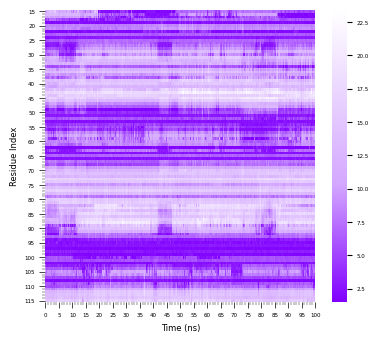

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

df = heatDat

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签

major_pos   = range(0, 1001, 50)
major_label = range(0, 101, 5)
minor_pos   = range(0, 1001, 10)

plt.xticks(major_pos, major_label, rotation=0)
ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_pos))
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)

plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)

plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)

plt.savefig("HeatMap_RNA_2.png", dpi=600)
plt.savefig("HeatMap_RNA_2.svg", dpi=600)
# plt.savefig("HeatMap_test.pdf", dpi=600)
# plt.savefig("HeatMap_test.svg", dpi=600)

plt.show()
